# Notebook 4.1: Implementing Deep Learning Projects

This notebook presents strategies and tutorials for efficiently running deep learning experiments.

In [ ]:
!pip install -q https://raw.githubusercontent.com/calpoly-data4620/DATA-4620-Labs/refs/heads/main/requirements.txt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Working with data in Pandas

[Pandas](https://pandas.pydata.org) is a widely-used Python library for working with tabular data.

The `ucimlrepo` package that we have been using loads data as Pandas DataFrames.  If you wanted to load data from a CSV file directly, you could do `df = pd.read_csv(filename)` to obtain a DataFrame.

If you are working in VS Code, I recommend you install the "Data Wrangler" extension, which provides a great viewer for Pandas DataFrames.  

Here I will load the [California Housing Dataset](https://www.kaggle.com/datasets/camnugent/california-housing-prices#) which I downloaded from Kaggle.

In [3]:
import pandas as pd
url = 'https://www.dropbox.com/scl/fi/cpce5si28h5oqnzfpdipw/housing.csv?rlkey=3di6mggl0v65gpmuo1g1gsuq0&dl=1'
df = pd.read_csv(url)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


Pandas makes it easy to do things like selecting rows and columns or applying various operations to data in the table.

For example, here we remove rows with missing values with `.dropna()`, and then separate out the predictor variables from the target variable.

In [4]:
df = df.dropna()
X = df[['longitude','latitude','housing_median_age','total_rooms','total_bedrooms','population','households','median_income','ocean_proximity']]
y = df['median_house_value']

### Data preprocessing

Now let's look at how to preprocess data using scikit learn.

`StandardScaler` applies standard scaling, meaning that we subtract the mean and divide by the std. dev.

`.fit(X)` will compute the mean and std. dev., and `.transform(X)` apply the normalization.  `fit_transform(X)` does both in the same call.

In [5]:
from sklearn.preprocessing import StandardScaler

quant_cols = ['longitude','latitude','housing_median_age','total_rooms','total_bedrooms','population','households','median_income']
StandardScaler().fit_transform(X[quant_cols])

array([[-1.32731375,  1.05171726,  0.98216331, ..., -0.97331952,
        -0.97683327,  2.34516291],
       [-1.32232256,  1.04235526, -0.60621017, ...,  0.86133924,
         1.67037262,  2.33263161],
       [-1.33230494,  1.03767426,  1.85576873, ..., -0.81976943,
        -0.84342665,  1.78293943],
       ...,
       [-0.82320322,  1.77727236, -0.92388486, ..., -0.36882637,
        -0.17377773, -1.14317103],
       [-0.87311515,  1.77727236, -0.84446619, ..., -0.60356386,
        -0.39350628, -1.05513604],
       [-0.83318561,  1.74918635, -1.00330353, ..., -0.03348711,
         0.07995643, -0.78060586]])

If we have categorical variables, like the `ocean_proximity` column in our dataset, we need to convert them to numeric before we can use them.  

`OrdinalEncoder` will map categorical variables to ordinals (0,1,2,3,...). This is typicall not a good idea, because the network will, for example, interpret a 2 as twice a 1, which doesn't make sense for most categorical variables.  

A better option is to map each category to its own Boolean column, with a 1 indicating which class the observation belongs to.  This is done using the `OneHotEncoder`.

When we `fit` the `OneHotEncoder`, it determines all of the unique values in the column.

In [6]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
encoder.fit(X[['ocean_proximity']])
encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

Now we can transform the column into zeros and ones.

Note that `OneHotEncoder` produces a sparse matrix, which we convert to dense using `.todense()`.

In [7]:
encoder.transform(X[['ocean_proximity']]).todense()

matrix([[0., 0., 0., 1., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 1., 0.],
        ...,
        [0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 0.]])

Since we likely want to preprocess different columns in different ways, we can combine different preprocessors into a single `ColumnTransformer` object using the `make_column_transformer` function.

Note that we need a separate `OneHotEncoder` object for each categorical column, since each one will have its own list of categories.

The final argument `remainder='drop'` tells the `ColumnTransformer` to ignore any columns that aren't listed in the previous arguments.  The alternative is `passthrough` which will keep the columns without modification.

In [8]:
from sklearn.compose import make_column_transformer

transformer = make_column_transformer(
    (StandardScaler(),quant_cols),
    (OneHotEncoder(),['ocean_proximity']),
    remainder='drop'
)

transformer.fit(X)

ColumnTransformer(transformers=[('standardscaler', StandardScaler(),
                                 ['longitude', 'latitude', 'housing_median_age',
                                  'total_rooms', 'total_bedrooms', 'population',
                                  'households', 'median_income']),
                                ('onehotencoder', OneHotEncoder(),
                                 ['ocean_proximity'])])

Now we can transform all of the columns in our `DataFrame` at once.

In [9]:
X_transformed = transformer.transform(X)
X_transformed.shape

(20433, 13)

In [10]:
X_transformed

array([[-1.32731375,  1.05171726,  0.98216331, ...,  0.        ,
         1.        ,  0.        ],
       [-1.32232256,  1.04235526, -0.60621017, ...,  0.        ,
         1.        ,  0.        ],
       [-1.33230494,  1.03767426,  1.85576873, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.82320322,  1.77727236, -0.92388486, ...,  0.        ,
         0.        ,  0.        ],
       [-0.87311515,  1.77727236, -0.84446619, ...,  0.        ,
         0.        ,  0.        ],
       [-0.83318561,  1.74918635, -1.00330353, ...,  0.        ,
         0.        ,  0.        ]])

### Train/test split

Before we saw how to use the `sklearn.model_selection.train_test_split` to split our data into train/test splits.  I will show you how to do it with PyTorch datasets, which is a more scalable option since Pandas requires the dataset to be loaded into memory.

Note that the `Dataset` object contains both the features and the targets, so we don't need to have separate variables for `X` and `y`.

In [11]:
import torch
import numpy as np

First we get our data into torch tensors of the appropriate type and shape.

In [12]:
X_tensor = torch.tensor(X_transformed).float()

In [13]:
log_y_tensor = torch.tensor(np.log(y.values)).float().unsqueeze(-1)

Now we make a `TensorDataset` and call `random_split` to split it.

In [14]:
from torch.utils.data import TensorDataset,random_split
ds = TensorDataset(X_tensor,log_y_tensor)
train_ds,test_ds = random_split(ds,[0.8,0.2])

As usual we will put our datasets into `DataLoader`s for shuffling and batching.

In [15]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

Now let's set up a simple neural network and get ready to optimize it.

In [ ]:
from torch import nn

model = nn.Sequential(
    nn.Linear(X_transformed.shape[-1],1),
)

loss_fn = nn.MSELoss()

opt = torch.optim.Adam(model.parameters(), lr=3e-4)

### Calculating metrics with Torch Metrics

The Torch Metrics library makes it easy to compute metrics like accuracy over batches.

The concept of the library is that you instantiate a metric object like `Accuracy` or `MeanSquaredError`, call it on each batch, and then at the end of the loop call `compute()` to compute the aggregated metric.

In [ ]:
from torchmetrics.regression import MeanSquaredError

metric = MeanSquaredError()

def compute_metric(model,loader):
    metric.reset()
    for (X_batch,y_batch) in train_loader:
        preds = model(X_batch)
        metric(preds,y_batch)
    return metric.compute()

In [ ]:
from tqdm import tqdm

for epoch in range(10):
    model.train() # put the model into "train" mode
    for (X_batch,y_batch) in tqdm(train_loader,desc=f'epoch {epoch}'):
        opt.zero_grad()

        z = model(X_batch)
        loss = loss_fn(z,y_batch)

        loss.backward()
        opt.step()

    model.eval() # put the model into "eval" mode
    train_mse = compute_metric(model,train_loader)
    test_mse = compute_metric(model,test_loader)

    print(f'train mse: {train_mse}, test mse: {test_mse}')

epoch 0: 100%|██████████| 511/511 [00:00<00:00, 1092.32it/s]


train mse: 131.18972778320312, test mse: 131.18972778320312


epoch 1: 100%|██████████| 511/511 [00:00<00:00, 1249.65it/s]


train mse: 128.97943115234375, test mse: 127.87425994873047


epoch 2: 100%|██████████| 511/511 [00:00<00:00, 1353.61it/s]


...

train mse: 110.8008804321289, test mse: 109.44329833984375


epoch 8: 100%|██████████| 511/511 [00:00<00:00, 1345.45it/s]


train mse: 107.93537902832031, test mse: 106.5951919555664


epoch 9: 100%|██████████| 511/511 [00:00<00:00, 1194.49it/s]


train mse: 105.1278076171875, test mse: 103.80713653564453


### Simplifying the process with PyTorch Lightning

Training a network with PyTorch involves a lot of boilerplate code that is repeated across projects.  PyTorch Lightning provides a framework where the boilerplate is taken care of for you, allowing you to focus on writing only the customized parts of your setup.

Here we create a `LightningModule` that will contain the NN model as well as the loss function and optimizer.  The module specifies how to run the model and compute the loss.

In [ ]:
import lightning as L

class LitModel(L.LightningModule):
    def __init__(self):
        super().__init__()

        # define the model
        self.model = nn.Sequential(
            nn.Linear(X_transformed.shape[-1],1),
        )

        # define the loss function
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        preds = self.model(x)
        return preds
    
    def common_step(self, batch, phase):
        X_batch, y_batch = batch
        preds = self.model(X_batch)
        loss = self.loss_fn(preds, y_batch)
        self.log(f"{phase}_loss", loss, on_epoch=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self.common_step(batch,'train')

    def validation_step(self, batch, batch_idx):
        return self.common_step(batch,'val')

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=3e-4)
        return optimizer


Now we can create a `Logger` object, to write metrics to a CSV file, and a `Trainer` object which will run the training process.

Note that by specifying the argument `accelerator=gpu` to `Trainer` we can run training on the GPU (if we have one).

In [ ]:
logger = L.pytorch.loggers.CSVLogger(save_dir="./",version='experiment')
trainer = L.Trainer(max_epochs=10,check_val_every_n_epoch=1,logger=logger)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Finally, we create the model and call `fit()`!

In [ ]:
litmodel = LitModel()
trainer.fit(litmodel, train_loader, test_loader)

/Users/jventu09/Library/CloudStorage/OneDrive-CalPoly/Teaching/CSC 487/.venv/lib/python3.9/site-packages/lightning/fabric/loggers/csv_logs.py:268: Experiment logs directory ./lightning_logs/experiment exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
/Users/jventu09/Library/CloudStorage/OneDrive-CalPoly/Teaching/CSC 487/.venv/lib/python3.9/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory ./lightning_logs/experiment/checkpoints exists and is not empty.


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Sequential │     14 │ train │     0 │
│ 1 │ loss_fn │ MSELoss    │      0 │ train │     0 │
└───┴─────────┴────────────┴────────┴───────┴───────┘

Trainable params: 14                                                                                               
Non-trainable params: 0                                                                                            
Total params: 14                                                                                                   
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/jventu09/Library/CloudStorage/OneDrive-CalPoly/Teaching/CSC 
487/.venv/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.

/Users/jventu09/Library/CloudStorage/OneDrive-CalPoly/Teaching/CSC 
487/.venv/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=10` reached.


Here is a little code to read in the metrics and make a plot of train and validation loss.

For more sophisticated logging, you can explore other loggers such as `TensorboardLogger` and `WandbLogger`.

<Axes: xlabel='epoch', ylabel='loss'>

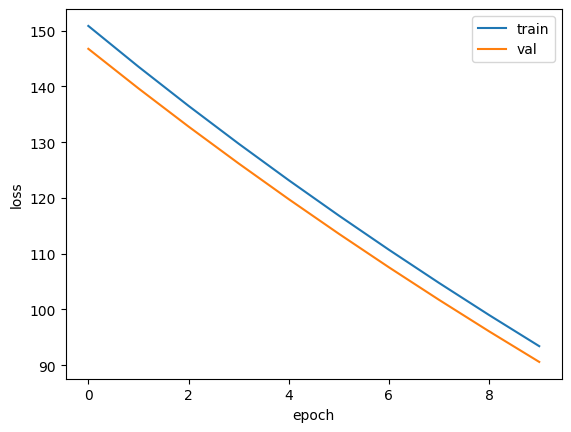

In [ ]:
# read the metrics.csv file
metrics = pd.read_csv('lightning_logs/experiment/metrics.csv')

# grab the train and val loss values
train = metrics['train_loss_epoch'].dropna().values
val = metrics['val_loss'].dropna().values

# make a DataFrame with the values
my_metrics = pd.DataFrame({'epochs':np.arange(len(train)),'train':train,'val':val})

# make a line plot
my_metrics[['train','val']].plot.line(xlabel='epoch',ylabel='loss')